# Raw PPG Signal Analysis

This notebook analyzes the raw PPG (Photoplethysmography) signals from the dataset to extract meaningful features for glucose level prediction.

In [1]:
# Import required libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import signal, stats
from scipy.fft import fft, fftfreq
import glob
import os
import warnings

warnings.filterwarnings('ignore')
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (15, 6)

## 1. Load Raw PPG Signals and Labels

In [2]:
# Get all raw signal files
signal_files = sorted(glob.glob('data/PPG_Dataset/RawData/signal_*.csv'))
label_files = sorted(glob.glob('data/PPG_Dataset/Labels/label_*.csv'))

print(f"Number of signal files: {len(signal_files)}")
print(f"Number of label files: {len(label_files)}")
print(f"\nFirst 5 signal files:")
for f in signal_files[:5]:
    print(f"  {os.path.basename(f)}")

Number of signal files: 67
Number of label files: 67

First 5 signal files:
  signal_01_0001.csv
  signal_01_0002.csv
  signal_01_0003.csv
  signal_01_0004.csv
  signal_01_0005.csv


In [3]:
# Load one sample signal to understand the structure
sample_signal = pd.read_csv(signal_files[0], header=None)
sample_label = pd.read_csv(label_files[0])

print("Sample Signal Shape:", sample_signal.shape)
print("\nSample Signal Statistics:")
print(sample_signal[0].describe())
print("\nSample Label:")
print(sample_label)

Sample Signal Shape: (21900, 1)

Sample Signal Statistics:
count    21900.000000
mean       511.866895
std          4.514529
min        495.000000
25%        509.000000
50%        511.000000
75%        513.000000
max        526.000000
Name: 0, dtype: float64

Sample Label:
   ID Gender  Age  Glucose  Height  Weight
0   1   Male   38       99     180      53


## 2. Visualize Raw PPG Waveforms

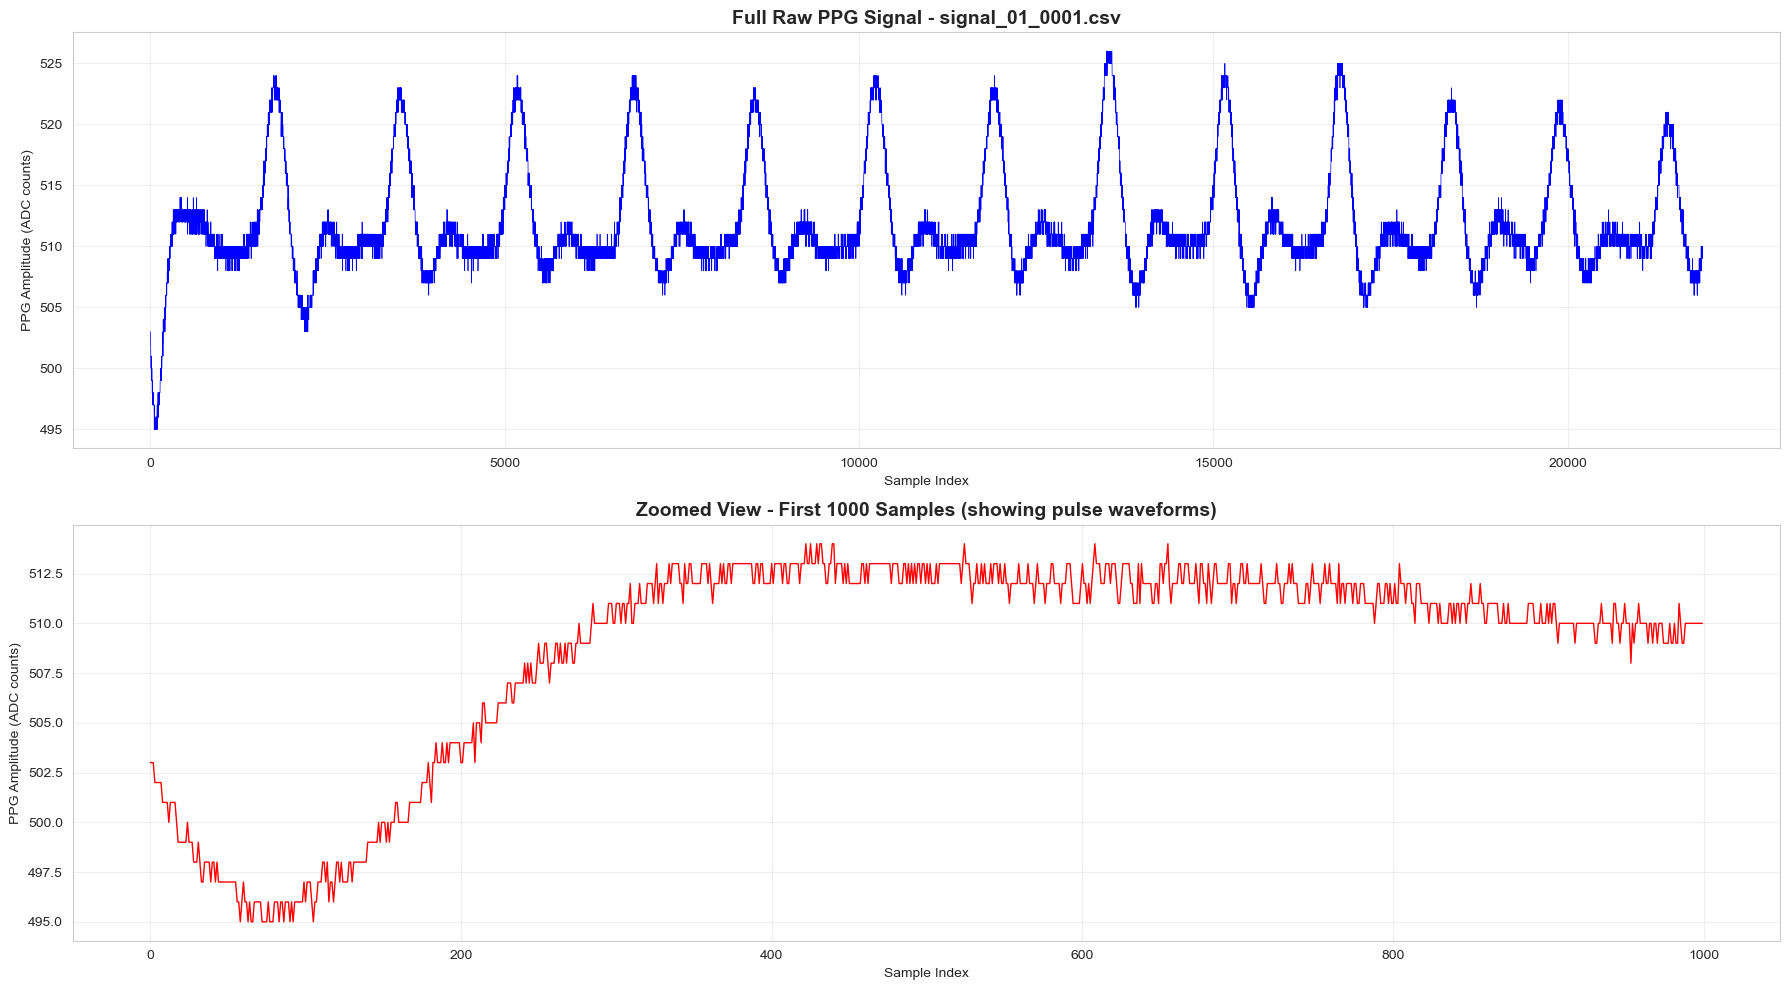

Signal length: 21900 samples
Signal range: 495 - 526
Signal mean: 511.87
Signal std: 4.51


In [4]:
# Plot the first raw PPG signal
ppg_signal = sample_signal[0].values

fig, axes = plt.subplots(2, 1, figsize=(18, 10))

# Full signal
axes[0].plot(ppg_signal, linewidth=0.5, color='blue')
axes[0].set_title(f'Full Raw PPG Signal - {os.path.basename(signal_files[0])}', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Sample Index')
axes[0].set_ylabel('PPG Amplitude (ADC counts)')
axes[0].grid(True, alpha=0.3)

# Zoomed view (first 1000 samples to see waveform details)
axes[1].plot(ppg_signal[:1000], linewidth=1, color='red')
axes[1].set_title('Zoomed View - First 1000 Samples (showing pulse waveforms)', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Sample Index')
axes[1].set_ylabel('PPG Amplitude (ADC counts)')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"Signal length: {len(ppg_signal)} samples")
print(f"Signal range: {ppg_signal.min()} - {ppg_signal.max()}")
print(f"Signal mean: {ppg_signal.mean():.2f}")
print(f"Signal std: {ppg_signal.std():.2f}")

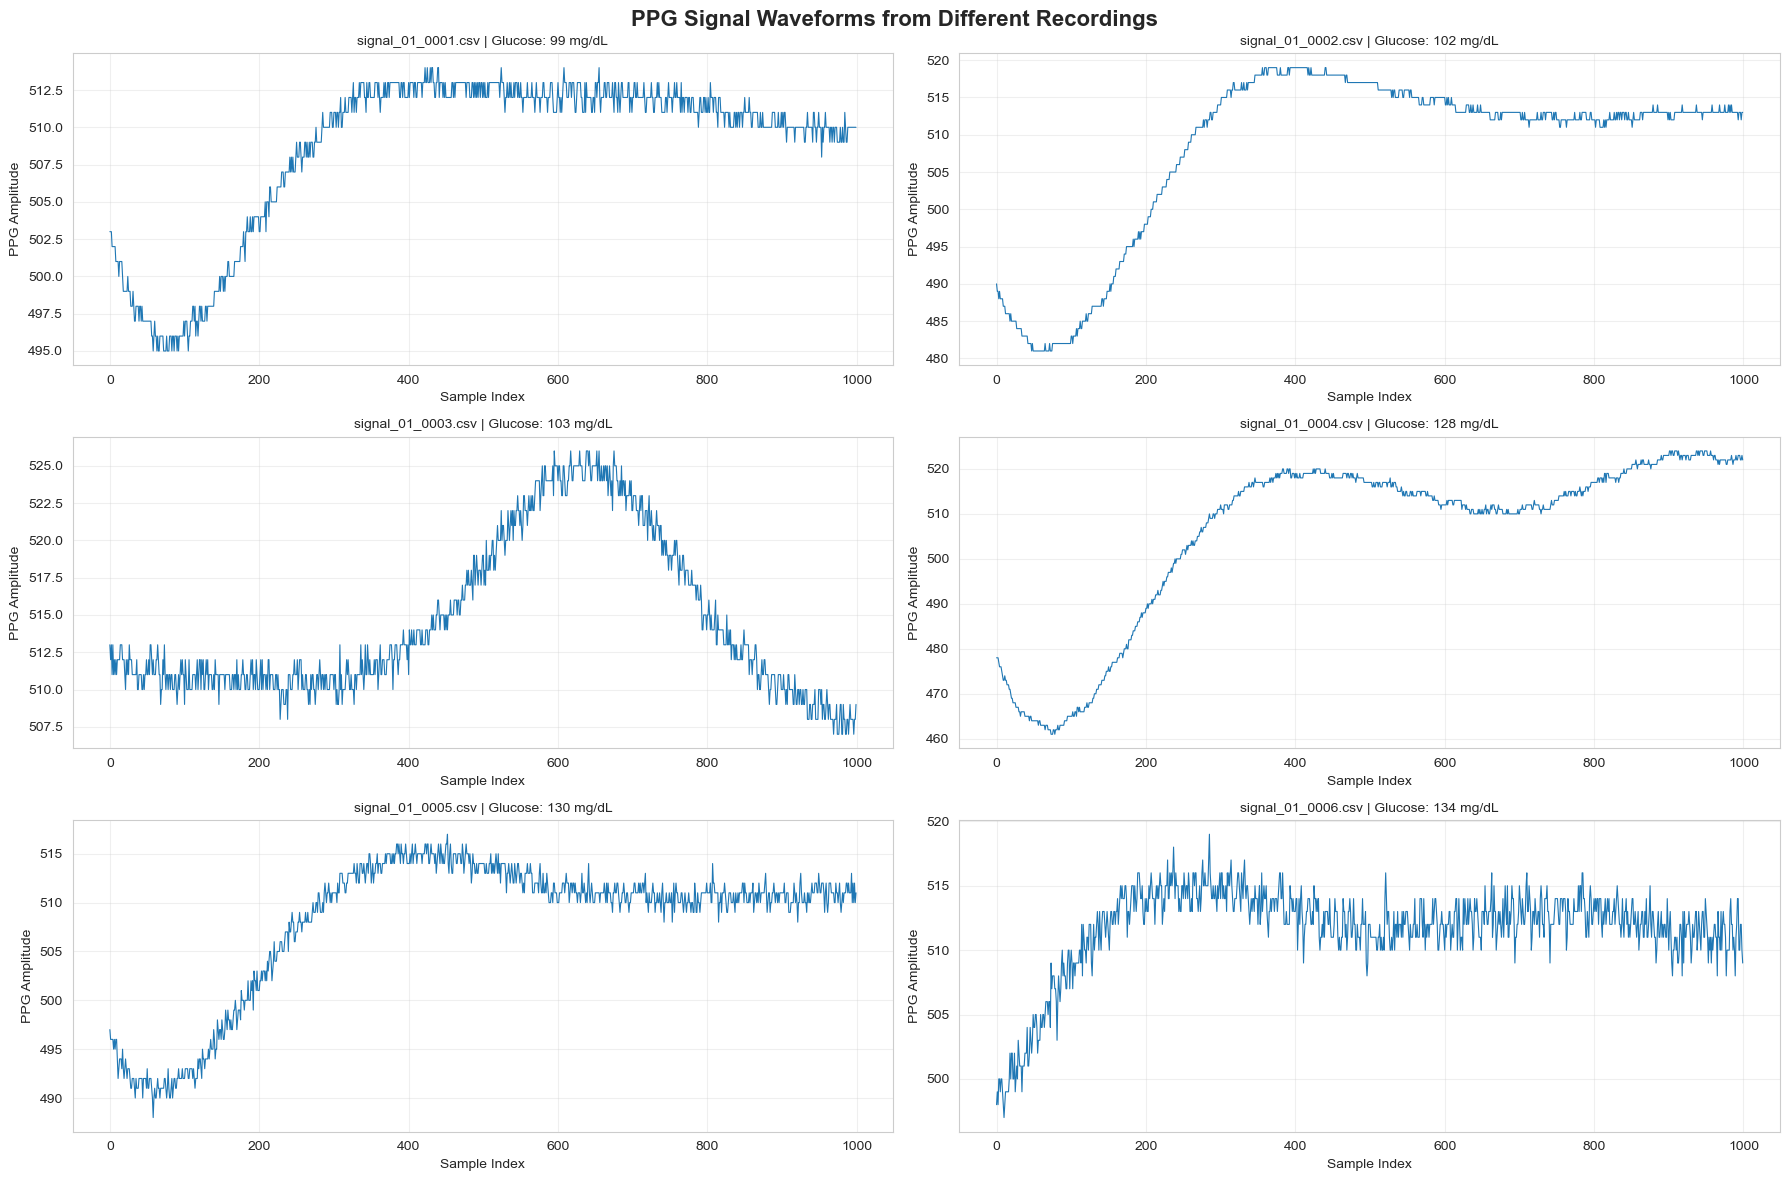

In [5]:
# Compare multiple PPG signals from different patients/sessions
fig, axes = plt.subplots(3, 2, figsize=(18, 12))
axes = axes.ravel()

for i, (sig_file, lbl_file) in enumerate(zip(signal_files[:6], label_files[:6])):
    sig = pd.read_csv(sig_file, header=None)[0].values
    lbl = pd.read_csv(lbl_file)
    glucose = lbl['Glucose'].values[0]
    
    # Plot a window of the signal
    axes[i].plot(sig[:1000], linewidth=0.8)
    axes[i].set_title(f'{os.path.basename(sig_file)} | Glucose: {glucose} mg/dL', fontsize=10)
    axes[i].set_xlabel('Sample Index')
    axes[i].set_ylabel('PPG Amplitude')
    axes[i].grid(True, alpha=0.3)

plt.suptitle('PPG Signal Waveforms from Different Recordings', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

## 3. Signal Preprocessing and Filtering

Estimated sampling frequency: 121.7 Hz


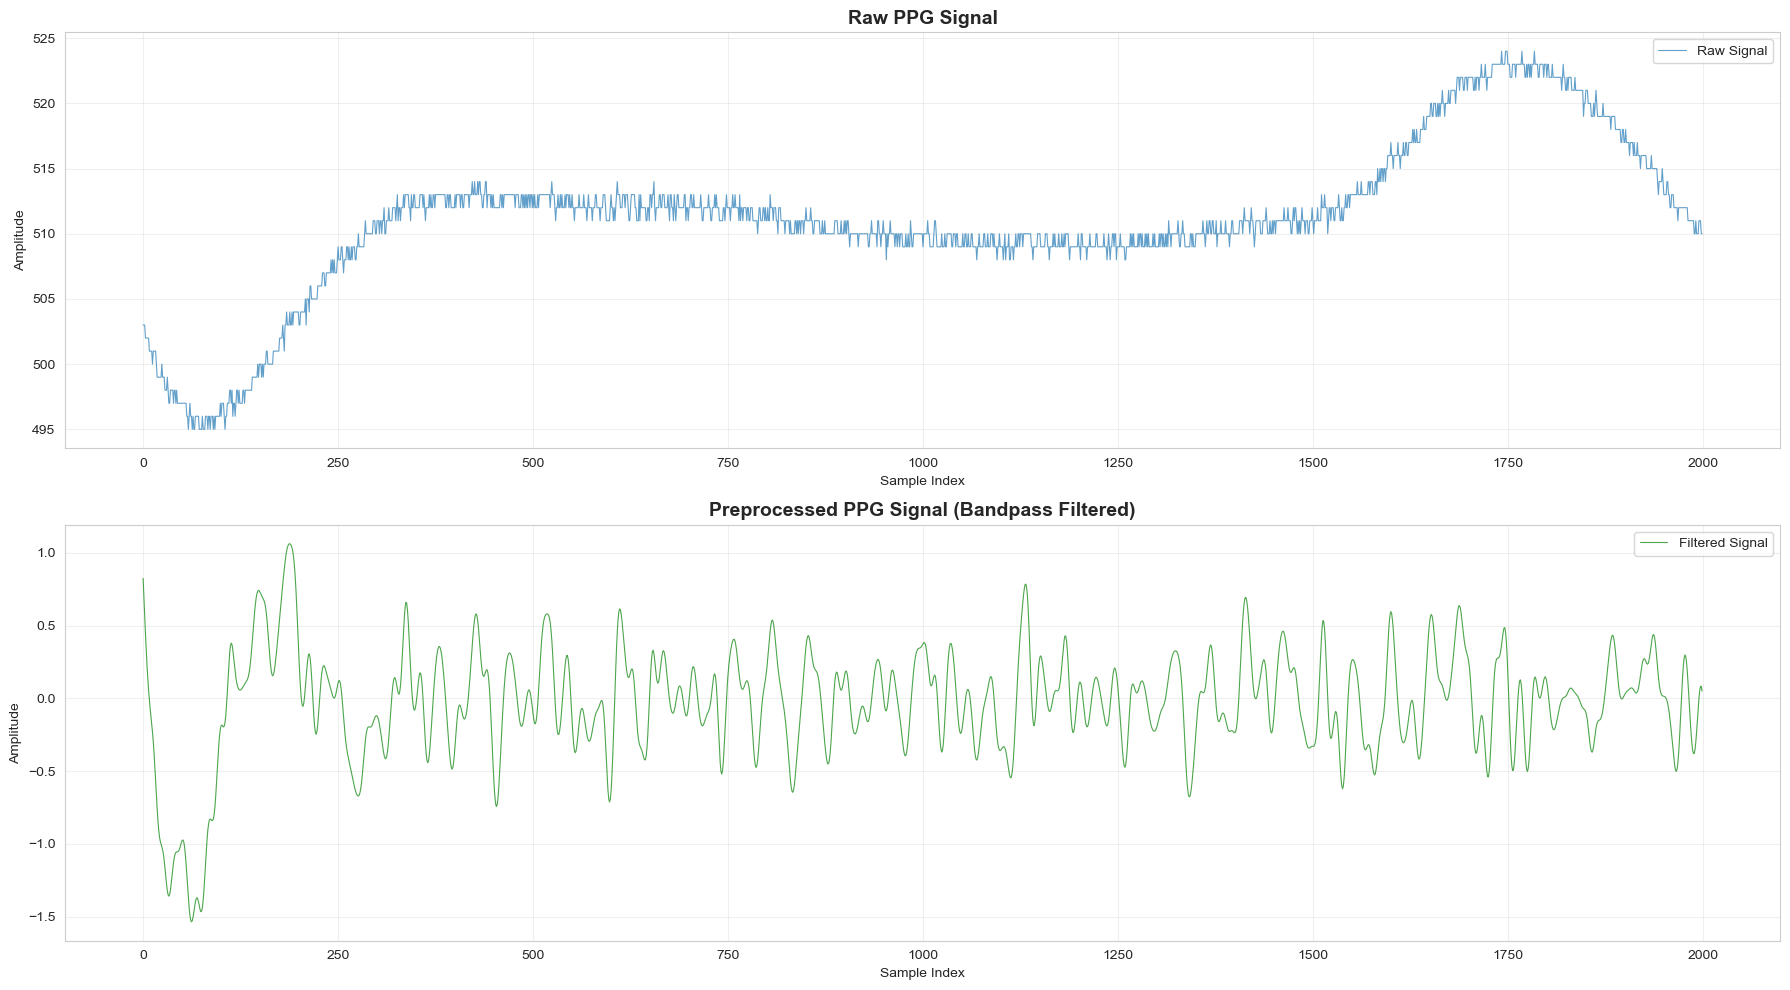

In [6]:
def preprocess_ppg_signal(ppg_signal, fs=125, lowcut=0.5, highcut=8.0):
    """
    Preprocess PPG signal with bandpass filtering
    
    Parameters:
    - ppg_signal: raw PPG signal
    - fs: sampling frequency (Hz) - estimated based on signal characteristics
    - lowcut: low cutoff frequency for bandpass filter
    - highcut: high cutoff frequency for bandpass filter
    """
    # Remove DC component (mean)
    ppg_normalized = ppg_signal - np.mean(ppg_signal)
    
    # Bandpass filter (0.5-8 Hz to capture heart rate range 30-480 bpm)
    nyquist = fs / 2
    low = lowcut / nyquist
    high = highcut / nyquist
    b, a = signal.butter(4, [low, high], btype='band')
    ppg_filtered = signal.filtfilt(b, a, ppg_normalized)
    
    return ppg_filtered

# Estimate sampling frequency based on signal length
# Assuming ~3 minutes (180 seconds) of recording
estimated_duration = 180  # seconds
fs = len(ppg_signal) / estimated_duration
print(f"Estimated sampling frequency: {fs:.1f} Hz")

# Preprocess the sample signal
ppg_filtered = preprocess_ppg_signal(ppg_signal, fs=fs)

# Visualize preprocessing effect
fig, axes = plt.subplots(2, 1, figsize=(18, 10))

axes[0].plot(ppg_signal[:2000], linewidth=0.8, label='Raw Signal', alpha=0.7)
axes[0].set_title('Raw PPG Signal', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Sample Index')
axes[0].set_ylabel('Amplitude')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].plot(ppg_filtered[:2000], linewidth=0.8, label='Filtered Signal', color='green', alpha=0.7)
axes[1].set_title('Preprocessed PPG Signal (Bandpass Filtered)', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Sample Index')
axes[1].set_ylabel('Amplitude')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 4. Peak Detection and Heart Rate Estimation

Number of peaks detected: 284
Estimated Heart Rate: 95.0 bpm
Heart Rate Variability (std): 27.90 bpm


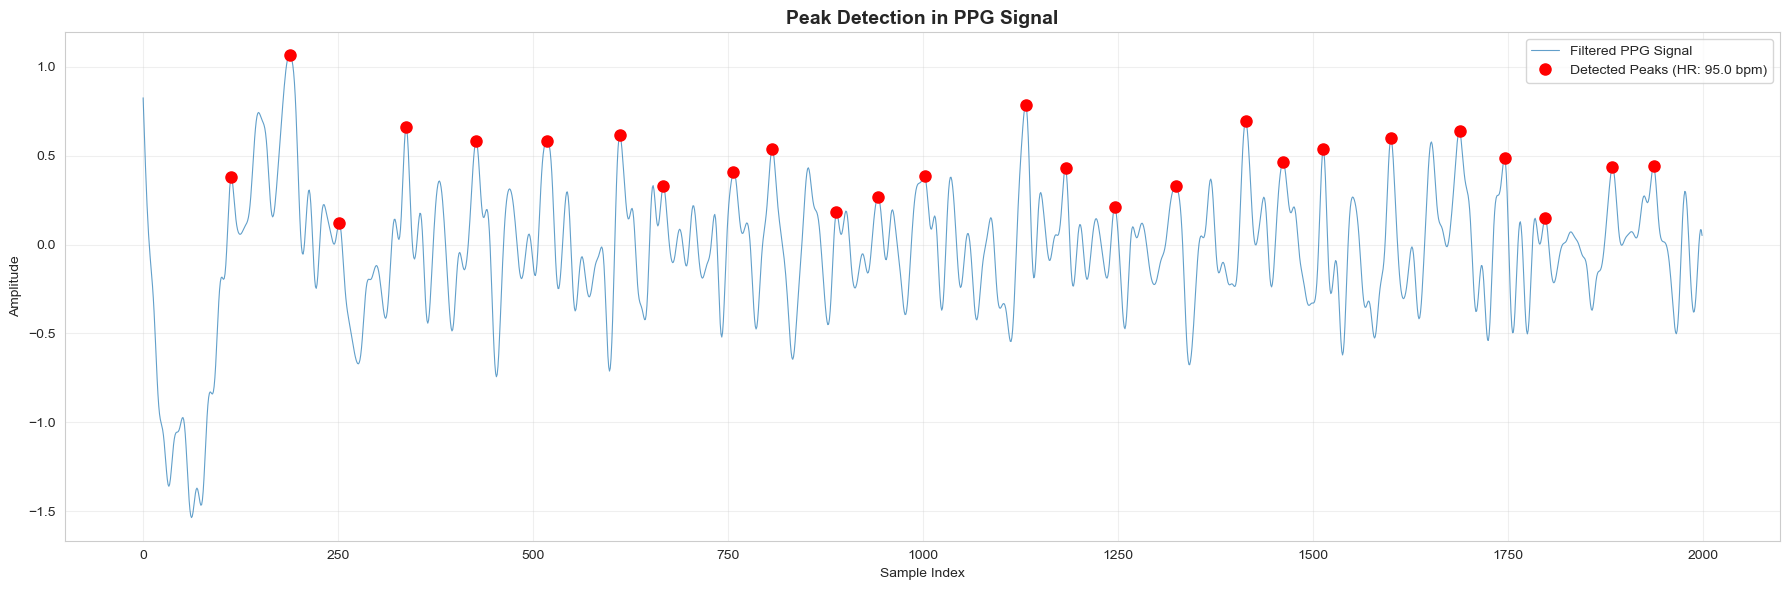

In [7]:
def detect_peaks_and_hr(ppg_filtered, fs):
    """
    Detect systolic peaks in PPG signal and calculate heart rate
    """
    # Find peaks (systolic peaks)
    peaks, properties = signal.find_peaks(ppg_filtered, 
                                          height=np.std(ppg_filtered)*0.3,
                                          distance=int(fs*0.4))  # Min 0.4s between peaks (max 150 bpm)
    
    # Calculate heart rate
    if len(peaks) > 1:
        peak_intervals = np.diff(peaks) / fs  # in seconds
        heart_rate = 60 / np.mean(peak_intervals)  # beats per minute
        hr_std = 60 * np.std(peak_intervals) / np.mean(peak_intervals)**2  # HR variability
    else:
        heart_rate = 0
        hr_std = 0
        peak_intervals = []
    
    return peaks, heart_rate, hr_std, peak_intervals

# Detect peaks
peaks, heart_rate, hr_std, peak_intervals = detect_peaks_and_hr(ppg_filtered, fs)

print(f"Number of peaks detected: {len(peaks)}")
print(f"Estimated Heart Rate: {heart_rate:.1f} bpm")
print(f"Heart Rate Variability (std): {hr_std:.2f} bpm")

# Visualize peak detection
plt.figure(figsize=(18, 6))
plt.plot(ppg_filtered[:2000], linewidth=0.8, label='Filtered PPG Signal', alpha=0.7)
plt.plot(peaks[peaks < 2000], ppg_filtered[peaks[peaks < 2000]], 'ro', 
         markersize=8, label=f'Detected Peaks (HR: {heart_rate:.1f} bpm)')
plt.title('Peak Detection in PPG Signal', fontsize=14, fontweight='bold')
plt.xlabel('Sample Index')
plt.ylabel('Amplitude')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 5. Time-Domain Feature Extraction

In [8]:
def extract_time_domain_features(ppg_signal, ppg_filtered, peaks, peak_intervals, fs):
    """
    Extract time-domain features from PPG signal
    """
    features = {}
    
    # Basic statistical features
    features['mean'] = np.mean(ppg_signal)
    features['std'] = np.std(ppg_signal)
    features['median'] = np.median(ppg_signal)
    features['min'] = np.min(ppg_signal)
    features['max'] = np.max(ppg_signal)
    features['range'] = features['max'] - features['min']
    features['skewness'] = stats.skew(ppg_signal)
    features['kurtosis'] = stats.kurtosis(ppg_signal)
    
    # Peak-based features
    if len(peaks) > 0:
        features['num_peaks'] = len(peaks)
        features['mean_peak_amplitude'] = np.mean(ppg_filtered[peaks])
        features['std_peak_amplitude'] = np.std(ppg_filtered[peaks])
        
        # Heart rate features
        if len(peak_intervals) > 0:
            features['mean_hr'] = 60 / np.mean(peak_intervals)
            features['std_hr'] = 60 * np.std(peak_intervals) / np.mean(peak_intervals)**2
            features['min_hr'] = 60 / np.max(peak_intervals)
            features['max_hr'] = 60 / np.min(peak_intervals)
            
            # Heart Rate Variability (HRV) features
            features['rmssd'] = np.sqrt(np.mean(np.diff(peak_intervals)**2))  # Root Mean Square of Successive Differences
            features['sdnn'] = np.std(peak_intervals)  # Standard Deviation of NN intervals
            
            # Pulse wave features
            if len(peaks) > 1:
                # Calculate pulse width at half maximum
                pulse_widths = []
                for i in range(min(len(peaks)-1, 10)):  # Sample first 10 pulses
                    peak_idx = peaks[i]
                    peak_val = ppg_filtered[peak_idx]
                    half_max = peak_val / 2
                    
                    # Find width at half maximum
                    left_idx = peak_idx
                    while left_idx > 0 and ppg_filtered[left_idx] > half_max:
                        left_idx -= 1
                    right_idx = peak_idx
                    while right_idx < len(ppg_filtered)-1 and ppg_filtered[right_idx] > half_max:
                        right_idx += 1
                    
                    pulse_widths.append((right_idx - left_idx) / fs)
                
                features['mean_pulse_width'] = np.mean(pulse_widths) if pulse_widths else 0
                features['std_pulse_width'] = np.std(pulse_widths) if pulse_widths else 0
    else:
        features['num_peaks'] = 0
        features['mean_peak_amplitude'] = 0
        features['std_peak_amplitude'] = 0
        features['mean_hr'] = 0
        features['std_hr'] = 0
        features['min_hr'] = 0
        features['max_hr'] = 0
        features['rmssd'] = 0
        features['sdnn'] = 0
        features['mean_pulse_width'] = 0
        features['std_pulse_width'] = 0
    
    return features

# Extract features from sample signal
time_features = extract_time_domain_features(ppg_signal, ppg_filtered, peaks, peak_intervals, fs)

print("Time-Domain Features:")
print("-" * 50)
for key, value in time_features.items():
    print(f"{key:25}: {value:.4f}")

Time-Domain Features:
--------------------------------------------------
mean                     : 511.8669
std                      : 4.5144
median                   : 511.0000
min                      : 495.0000
max                      : 526.0000
range                    : 31.0000
skewness                 : 0.9466
kurtosis                 : 1.2171
num_peaks                : 284.0000
mean_peak_amplitude      : 0.4619
std_peak_amplitude       : 0.1779
mean_hr                  : 94.9621
std_hr                   : 27.9002
min_hr                   : 50.3448
max_hr                   : 152.0833
rmssd                    : 0.2665
sdnn                     : 0.1856
mean_pulse_width         : 0.1052
std_pulse_width          : 0.0376


## 6. Frequency-Domain Feature Extraction

Frequency-Domain Features:
--------------------------------------------------
vlf_power                : 26463.6438
lf_power                 : 76374.5311
hf_power                 : 456470.8541
total_power              : 19535085.2069
lf_hf_ratio              : 0.1673
lf_norm                  : 0.1433
hf_norm                  : 0.8567
dominant_frequency       : 2.5833
dominant_power           : 6716521.8211
spectral_entropy         : 6.8951


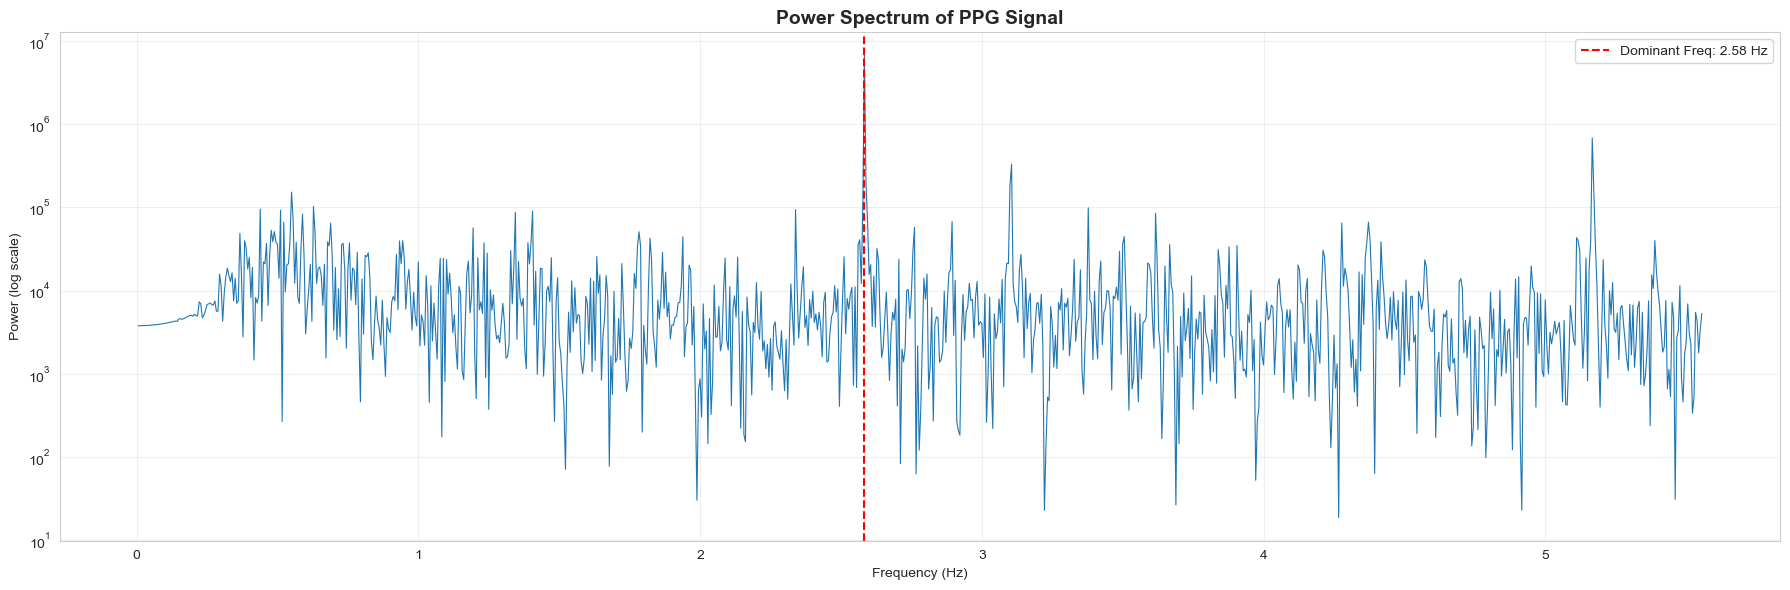

In [9]:
def extract_frequency_domain_features(ppg_signal, fs):
    """
    Extract frequency-domain features using FFT
    """
    features = {}
    
    # Compute FFT
    N = len(ppg_signal)
    fft_vals = fft(ppg_signal - np.mean(ppg_signal))
    fft_freq = fftfreq(N, 1/fs)
    
    # Take positive frequencies only
    pos_mask = fft_freq > 0
    fft_freq = fft_freq[pos_mask]
    fft_power = np.abs(fft_vals[pos_mask])**2
    
    # Frequency bands (in Hz)
    vlf_band = (0.0, 0.04)   # Very Low Frequency
    lf_band = (0.04, 0.15)   # Low Frequency
    hf_band = (0.15, 0.4)    # High Frequency
    
    # Calculate power in each band
    vlf_power = np.sum(fft_power[(fft_freq >= vlf_band[0]) & (fft_freq < vlf_band[1])])
    lf_power = np.sum(fft_power[(fft_freq >= lf_band[0]) & (fft_freq < lf_band[1])])
    hf_power = np.sum(fft_power[(fft_freq >= hf_band[0]) & (fft_freq < hf_band[1])])
    total_power = np.sum(fft_power)
    
    features['vlf_power'] = vlf_power
    features['lf_power'] = lf_power
    features['hf_power'] = hf_power
    features['total_power'] = total_power
    features['lf_hf_ratio'] = lf_power / hf_power if hf_power > 0 else 0
    features['lf_norm'] = lf_power / (lf_power + hf_power) if (lf_power + hf_power) > 0 else 0
    features['hf_norm'] = hf_power / (lf_power + hf_power) if (lf_power + hf_power) > 0 else 0
    
    # Dominant frequency
    dominant_freq_idx = np.argmax(fft_power)
    features['dominant_frequency'] = fft_freq[dominant_freq_idx]
    features['dominant_power'] = fft_power[dominant_freq_idx]
    
    # Spectral entropy
    normalized_power = fft_power / np.sum(fft_power)
    features['spectral_entropy'] = -np.sum(normalized_power * np.log2(normalized_power + 1e-10))
    
    return features, fft_freq, fft_power

# Extract frequency features
freq_features, fft_freq, fft_power = extract_frequency_domain_features(ppg_filtered, fs)

print("Frequency-Domain Features:")
print("-" * 50)
for key, value in freq_features.items():
    print(f"{key:25}: {value:.4f}")

# Visualize frequency spectrum
plt.figure(figsize=(18, 6))
plt.semilogy(fft_freq[:1000], fft_power[:1000], linewidth=0.8)
plt.axvline(x=freq_features['dominant_frequency'], color='r', linestyle='--', 
            label=f"Dominant Freq: {freq_features['dominant_frequency']:.2f} Hz")
plt.title('Power Spectrum of PPG Signal', fontsize=14, fontweight='bold')
plt.xlabel('Frequency (Hz)')
plt.ylabel('Power (log scale)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 7. Process All Signals and Create Feature Dataset

In [10]:
def process_all_signals(signal_files, label_files, fs=122):
    """
    Process all PPG signals and extract features
    """
    all_features = []
    
    for sig_file, lbl_file in zip(signal_files, label_files):
        try:
            # Load signal and label
            ppg_raw = pd.read_csv(sig_file, header=None)[0].values
            label_data = pd.read_csv(lbl_file)
            
            # Preprocess signal
            ppg_filtered = preprocess_ppg_signal(ppg_raw, fs=fs)
            
            # Detect peaks
            peaks, hr, hr_std, intervals = detect_peaks_and_hr(ppg_filtered, fs)
            
            # Extract time-domain features
            time_feat = extract_time_domain_features(ppg_raw, ppg_filtered, peaks, intervals, fs)
            
            # Extract frequency-domain features
            freq_feat, _, _ = extract_frequency_domain_features(ppg_filtered, fs)
            
            # Combine all features
            feature_dict = {
                'filename': os.path.basename(sig_file),
                'patient_id': label_data['ID'].values[0],
                'gender': label_data['Gender'].values[0],
                'age': label_data['Age'].values[0],
                'glucose_level': label_data['Glucose'].values[0],
                'height': label_data['Height'].values[0],
                'weight': label_data['Weight'].values[0],
                **time_feat,
                **freq_feat
            }
            
            all_features.append(feature_dict)
            
        except Exception as e:
            print(f"Error processing {sig_file}: {e}")
            continue
    
    return pd.DataFrame(all_features)

# Process all signals (this may take a minute)
print("Processing all signals...")
features_df = process_all_signals(signal_files, label_files, fs=fs)

print(f"\nFeature extraction complete!")
print(f"Dataset shape: {features_df.shape}")
print(f"\nFirst few rows:")
features_df.head()

Processing all signals...

Feature extraction complete!
Dataset shape: (67, 36)

First few rows:


,filename,patient_id,gender,age,glucose_level,height,weight,mean,std,median,...,vlf_power,lf_power,hf_power,total_power,lf_hf_ratio,lf_norm,hf_norm,dominant_frequency,dominant_power,spectral_entropy
0,signal_01_0001.csv,1,Male,38,99,180,53,511.866895,4.514426,511.0,...,26463.643784,76374.531102,4.564709e+05,1.953509e+07,0.167315,0.143333,0.856667,2.583333,6.716522e+06,6.895073
1,signal_01_0002.csv,1,Male,38,102,180,53,513.258767,2.919033,513.0,...,53770.332346,155215.193410,6.666069e+05,3.687807e+07,0.232844,0.188867,0.811133,2.577778,2.398001e+07,4.075505
2,signal_01_0003.csv,1,Male,38,103,180,53,512.897489,4.765452,511.0,...,3597.197443,10286.638201,1.134210e+05,3.146832e+07,0.090694,0.083153,0.916847,2.577778,2.856094e+06,8.377584
3,signal_01_0004.csv,1,Male,38,128,180,53,512.083790,6.402309,511.0,...,151530.183009,436864.190334,2.079298e+06,8.113965e+07,0.210102,0.173623,0.826377,2.577778,5.607089e+07,3.522607
4,signal_01_0005.csv,1,Male,38,130,180,53,511.439635,2.096172,512.0,...,35749.451550,102999.455132,4.775175e+05,3.540353e+07,0.215698,0.177427,0.822573,2.572222,7.125875e+06,7.709672


In [11]:
# Display all extracted features
print("\nAll Extracted Features:")
print("-" * 80)
for col in features_df.columns:
    print(f"  {col}")

print(f"\nTotal number of features: {len(features_df.columns)}")


All Extracted Features:
--------------------------------------------------------------------------------
  filename
  patient_id
  gender
  age
  glucose_level
  height
  weight
  mean
  std
  median
  min
  max
  range
  skewness
  kurtosis
  num_peaks
  mean_peak_amplitude
  std_peak_amplitude
  mean_hr
  std_hr
  min_hr
  max_hr
  rmssd
  sdnn
  mean_pulse_width
  std_pulse_width
  vlf_power
  lf_power
  hf_power
  total_power
  lf_hf_ratio
  lf_norm
  hf_norm
  dominant_frequency
  dominant_power
  spectral_entropy

Total number of features: 36


## 8. Feature Statistics and Correlations

In [12]:
# Summary statistics of extracted features
print("Feature Statistics:")
features_df.describe()

Feature Statistics:


,patient_id,age,glucose_level,height,weight,mean,std,median,min,max,...,vlf_power,lf_power,hf_power,total_power,lf_hf_ratio,lf_norm,hf_norm,dominant_frequency,dominant_power,spectral_entropy
count,67.000000,67.000000,67.000000,67.000000,67.000000,67.000000,67.000000,67.000000,67.000000,67.000000,...,67.000000,67.000000,6.700000e+01,6.700000e+01,67.000000,67.000000,67.000000,67.000000,6.700000e+01,67.000000
mean,10.537313,31.313433,115.014925,174.880597,69.194030,512.173982,3.532187,511.507463,489.552239,522.388060,...,29639.826137,85540.052454,4.342545e+05,9.353074e+07,0.162638,0.137084,0.862916,3.249668,4.434710e+07,6.129756
std,7.018004,9.434317,18.736201,8.585616,17.020699,0.835760,1.237729,1.049865,10.113423,3.721173,...,33965.544344,97633.122593,4.451452e+05,2.829980e+08,0.064953,0.051028,0.051028,1.257947,1.461675e+08,1.930194
min,1.000000,22.000000,88.000000,154.000000,42.000000,506.565936,1.150789,506.000000,461.000000,516.000000,...,22.174954,93.319302,2.094773e+04,5.857830e+06,0.003559,0.003546,0.796448,0.544444,2.572269e+05,2.477815
25%,4.500000,24.000000,102.500000,170.000000,56.000000,512.036849,2.745140,511.000000,484.000000,519.000000,...,6103.177021,18114.941801,1.339460e+05,2.365613e+07,0.136401,0.120015,0.822526,2.577778,4.295339e+06,4.524001
50%,10.000000,29.000000,110.000000,178.000000,62.000000,512.211826,3.495179,512.000000,491.000000,522.000000,...,15230.320492,46240.903695,2.721660e+05,3.112446e+07,0.178139,0.151204,0.848796,2.577778,1.067451e+07,6.343634
75%,16.500000,38.000000,125.500000,180.000000,88.000000,512.403562,4.061856,512.000000,494.000000,524.500000,...,43216.998051,124545.829078,5.617536e+05,5.126392e+07,0.215767,0.177474,0.879985,5.147222,2.444922e+07,7.630431
max,23.000000,61.000000,183.000000,187.000000,103.000000,513.569041,7.761892,514.000000,509.000000,534.000000,...,151530.183009,436864.190334,2.079298e+06,1.707496e+09,0.255574,0.203552,0.996454,5.183333,9.332487e+08,9.416620


In [13]:
# Correlation with glucose level
numeric_features = features_df.select_dtypes(include=[np.number]).columns.tolist()
correlations = features_df[numeric_features].corr()['glucose_level'].sort_values(ascending=False)

print("\nTop 15 Features Correlated with Glucose Level:")
print("-" * 60)
print(correlations.head(15))

print("\nBottom 15 Features Correlated with Glucose Level:")
print("-" * 60)
print(correlations.tail(15))


Top 15 Features Correlated with Glucose Level:
------------------------------------------------------------
glucose_level       1.000000
mean_hr             0.305040
num_peaks           0.295778
skewness            0.202338
age                 0.197207
hf_norm             0.184681
weight              0.180819
min                 0.155879
mean                0.117582
max                 0.112921
median              0.104365
spectral_entropy    0.085911
patient_id          0.075759
total_power         0.066154
height              0.057561
Name: glucose_level, dtype: float64

Bottom 15 Features Correlated with Glucose Level:
------------------------------------------------------------
dominant_frequency    0.000182
std_hr               -0.001751
std                  -0.002754
std_peak_amplitude   -0.023902
mean_pulse_width     -0.040781
hf_power             -0.090231
lf_power             -0.093810
vlf_power            -0.094453
range                -0.108692
rmssd                -0.17183

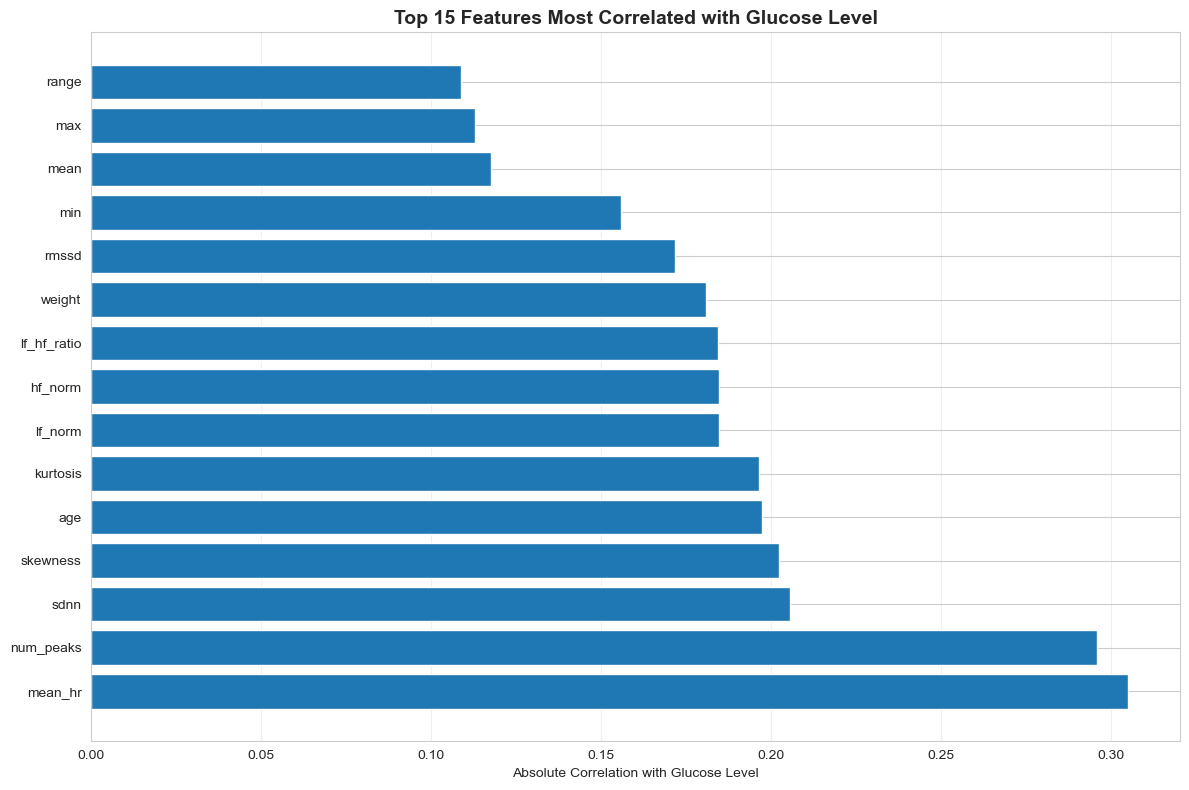

In [14]:
# Visualize feature correlations with glucose
plt.figure(figsize=(12, 8))
top_features = correlations.abs().sort_values(ascending=False)[1:16]  # Exclude glucose itself
plt.barh(range(len(top_features)), top_features.values)
plt.yticks(range(len(top_features)), top_features.index)
plt.xlabel('Absolute Correlation with Glucose Level')
plt.title('Top 15 Features Most Correlated with Glucose Level', fontsize=14, fontweight='bold')
plt.grid(True, alpha=0.3, axis='x')
plt.tight_layout()
plt.show()

## 9. Save Extracted Features

In [15]:
# Save the feature dataset
output_file = 'data/ppg_raw_features.csv'
features_df.to_csv(output_file, index=False)

print(f"Features saved to: {output_file}")
print(f"Dataset shape: {features_df.shape}")
print(f"\nFeature columns:")
print(list(features_df.columns))

Features saved to: data/ppg_raw_features.csv
Dataset shape: (67, 36)

Feature columns:
['filename', 'patient_id', 'gender', 'age', 'glucose_level', 'height', 'weight', 'mean', 'std', 'median', 'min', 'max', 'range', 'skewness', 'kurtosis', 'num_peaks', 'mean_peak_amplitude', 'std_peak_amplitude', 'mean_hr', 'std_hr', 'min_hr', 'max_hr', 'rmssd', 'sdnn', 'mean_pulse_width', 'std_pulse_width', 'vlf_power', 'lf_power', 'hf_power', 'total_power', 'lf_hf_ratio', 'lf_norm', 'hf_norm', 'dominant_frequency', 'dominant_power', 'spectral_entropy']
